In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("All imports successful!")

All imports successful!


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/chf_combined.csv")
df_lhs = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/lhs_samples.csv")
df_multi_stratified = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/multi_stratified_samples.csv")
df_random_samples = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/random_samples.csv")

#check that all datasets loaded properly
print("Combined dataset shape:", df.shape)
print("LHS samples shape:", df_lhs.shape)
print("Multi-stratified samples shape:", df_multi_stratified.shape)
print("Random samples shape:", df_random_samples.shape)
print("All datasets loaded successfully!")

Combined dataset shape: (2500, 7)
LHS samples shape: (1000, 7)
Multi-stratified samples shape: (1267, 7)
Random samples shape: (1000, 7)
All datasets loaded successfully!


In [ ]:
#pick target
target = "CHF (kW m-2)"

features = [col for col in df.columns if col != target]

In [5]:
#non sampled dataset
X = df[features]
y = df[target]

#80/20 train test split for non sampled data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_lhs = df_lhs[features]
y_lhs = df_lhs[target]
#80/20 train test split for LHS samples
X_train_lhs, X_test_lhs, y_train_lhs, y_test_lhs = train_test_split(X_lhs, y_lhs, test_size=0.2, random_state=42)

X_multi_stratified = df_multi_stratified[features]
y_multi_stratified = df_multi_stratified[target]
#80/20 train test split for multi-stratified samples
X_train_multi_stratified, X_test_multi_stratified, y_train_multi_stratified, y_test_multi_stratified = train_test_split(X_multi_stratified, y_multi_stratified, test_size=0.2, random_state=42)

X_random = df_random_samples[features]
y_random = df_random_samples[target]
#80/20 train test split for random samples
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(X_random, y_random, test_size=0.2, random_state=42)

In [6]:
#Preproccessing and Model Pipeline
from pyexpat import model


numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

model_deep = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        #we'll implement a narrow and deep architecture
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

model_shallow = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        #we'll implement a narrow and shallow architecture
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])


model_deep.fit(X_train, y_train)
model_shallow.fit(X_train, y_train)

#train models on alternate sampled datasets
model_deep.fit(X_train_lhs, y_train_lhs)
model_deep.fit(X_train_multi_stratified, y_train_multi_stratified)
model_deep.fit(X_train_random, y_train_random)

model_shallow.fit(X_train_lhs, y_train_lhs)
model_shallow.fit(X_train_multi_stratified, y_train_multi_stratified)
model_shallow.fit(X_train_random, y_train_random)

d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('nn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse mat

In [7]:
#Pred
y_pred = model_deep.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)




Neural Network Regression Results
---------------------------------
MSE : 22407433.685622428
RMSE: 4733.649087714723
MAE : 4535.12975592629
R^2 : -8.406280895657304


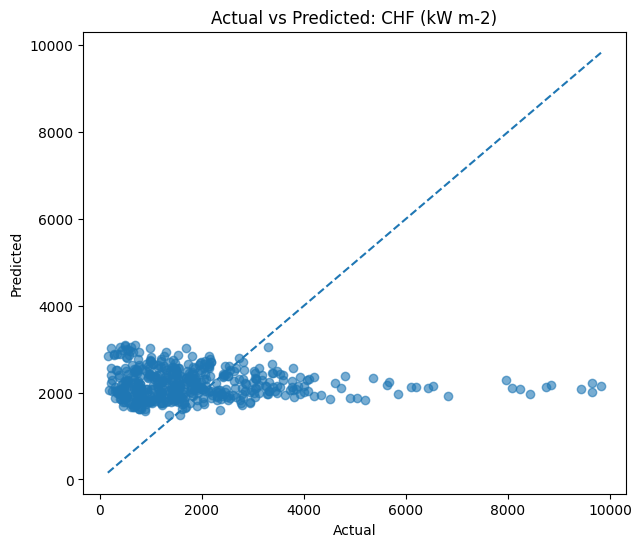

In [11]:
#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

# #Residual plot
# residuals = y_test - y_pred

# plt.figure(figsize=(7, 6))
# plt.scatter(y_pred, residuals, alpha=0.6)
# plt.axhline(0, linestyle="--")
# plt.xlabel("Predicted")
# plt.ylabel("Residuals")
# plt.title("Residual Plot")
# plt.show()

In [9]:
#Pred
y_pred = model_shallow.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)




Neural Network Regression Results
---------------------------------
MSE : 2684925.520700055
RMSE: 1638.5742341133207
MAE : 1216.6427415658306
R^2 : -0.12708862540686505


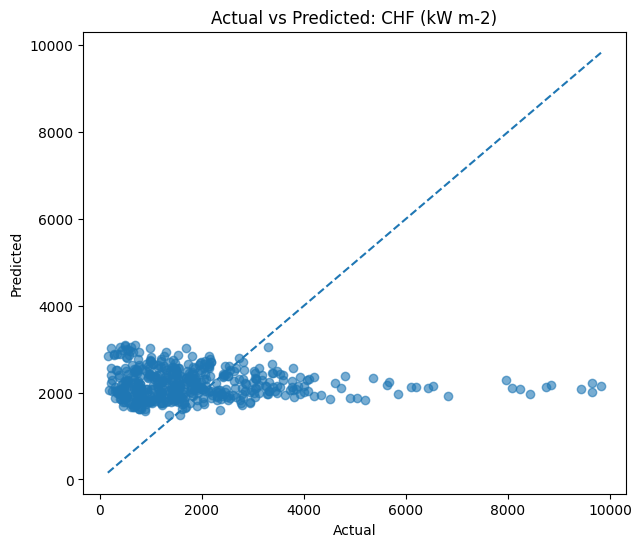

In [12]:
#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

# #Residual plot
# residuals = y_test - y_pred

# plt.figure(figsize=(7, 6))
# plt.scatter(y_pred, residuals, alpha=0.6)
# plt.axhline(0, linestyle="--")
# plt.xlabel("Predicted")
# plt.ylabel("Residuals")
# plt.title("Residual Plot")
# plt.show()

In [ ]:
for(model_name, model) in [("Deep NN", model_deep), ("Shallow NN", model_shallow)]:
    for (dataset_name, X_tr, y_tr) in [
        ("LHS Samples", X_train_lhs, y_train_lhs),
        ("Multi-Stratified Samples", X_train_multi_stratified, y_train_multi_stratified),
        ("Random Samples", X_train_random, y_train_random)
    ]:
        #train model on current dataset
        model.fit(X_tr, y_tr)
        
        #predict on test set
        y_pred = model.predict(X_test)
        
        #calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        #print results
        print(f"\n{model_name} - {dataset_name}")
        print("---------------------------------")
        print("MSE :", mse)
        print("RMSE:", rmse)
        print("MAE :", mae)
        print("R^2 :", r2)

d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Deep NN - LHS Samples
---------------------------------
MSE : 25346655.510372985
RMSE: 5034.546206995521
MAE : 4840.598506169561
R^2 : -9.640119026616038

Deep NN - Multi-Stratified Samples
---------------------------------
MSE : 71202.60871410431
RMSE: 266.8381695224735
MAE : 157.68758804657782
R^2 : 0.9701102880648852


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Deep NN - Random Samples
---------------------------------
MSE : 22407433.685622428
RMSE: 4733.649087714723
MAE : 4535.12975592629
R^2 : -8.406280895657304


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Shallow NN - LHS Samples
---------------------------------
MSE : 2368270.8282241235
RMSE: 1538.918720473607
MAE : 1109.2916388215028
R^2 : 0.005837930402502689


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Shallow NN - Multi-Stratified Samples
---------------------------------
MSE : 579985.2373410537
RMSE: 761.5676183642879
MAE : 561.3210526599966
R^2 : 0.7565315093952546

Shallow NN - Random Samples
---------------------------------
MSE : 2684925.520700055
RMSE: 1638.5742341133207
MAE : 1216.6427415658306
R^2 : -0.12708862540686505


d:\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
